# Analysis — What Do the Top 10% Most Popular Spotify Songs Have in Common?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../data/processed/spotify_cleaned.csv")
print("Loaded successfully!")
print(df.shape)

Loaded successfully!
(49999, 23)


In [2]:
# Define top 10% popularity threshold
threshold = df['popularity'].quantile(0.90)
print(f"Top 10% popularity threshold: {threshold}")

# Split into top 10% and the rest
top10 = df[df['popularity'] >= threshold]
rest  = df[df['popularity'] < threshold]

print(f"Top 10% songs: {len(top10)}")
print(f"Rest of songs: {len(rest)}")

Top 10% popularity threshold: 62.0
Top 10% songs: 5453
Rest of songs: 44546


In [3]:
# Compare average audio features between top 10% and the rest
features = ['danceability', 'energy', 'loudness', 
            'speechiness', 'acousticness', 'valence', 
            'tempo', 'instrumentalness']

comparison = pd.DataFrame({
    'top_10_percent': top10[features].mean(),
    'rest':           rest[features].mean()
})

comparison['difference'] = comparison['top_10_percent'] - comparison['rest']
print(comparison.round(3))

                  top_10_percent     rest  difference
danceability               0.597    0.562       0.034
energy                     0.657    0.640       0.017
loudness                  -7.261   -8.367       1.107
speechiness                0.077    0.085      -0.008
acousticness               0.254    0.321      -0.066
valence                    0.486    0.472       0.014
tempo                    120.733  122.392      -1.660
instrumentalness           0.063    0.167      -0.104


In [4]:
# What percentage of top 10% songs are explicit?
top10_explicit = top10['explicit'].mean() * 100
rest_explicit  = rest['explicit'].mean() * 100

print(f"Explicit in top 10%: {top10_explicit:.1f}%")
print(f"Explicit in rest:    {rest_explicit:.1f}%")

Explicit in top 10%: 13.4%
Explicit in rest:    7.8%


In [5]:
# Which genres dominate the top 10%?
top_genres = top10['track_genre'].value_counts().head(10)
print("Top 10 genres in the top 10% most popular songs:")
print(top_genres)

Top 10 genres in the top 10% most popular songs:
track_genre
pop          280
k-pop        204
metal        197
electro      181
house        177
pop-film     165
edm          165
hard-rock    146
indie-pop    145
grunge       125
Name: count, dtype: int64


In [6]:
# What tempo category do top 10% songs fall into?
print("Tempo category distribution in top 10%:")
print(top10['tempo_category'].value_counts())
print()
print("Tempo category distribution in rest:")
print(rest['tempo_category'].value_counts())

Tempo category distribution in top 10%:
tempo_category
medium    2944
fast      1784
slow       725
Name: count, dtype: int64

Tempo category distribution in rest:
tempo_category
medium    21537
fast      16534
slow       6475
Name: count, dtype: int64


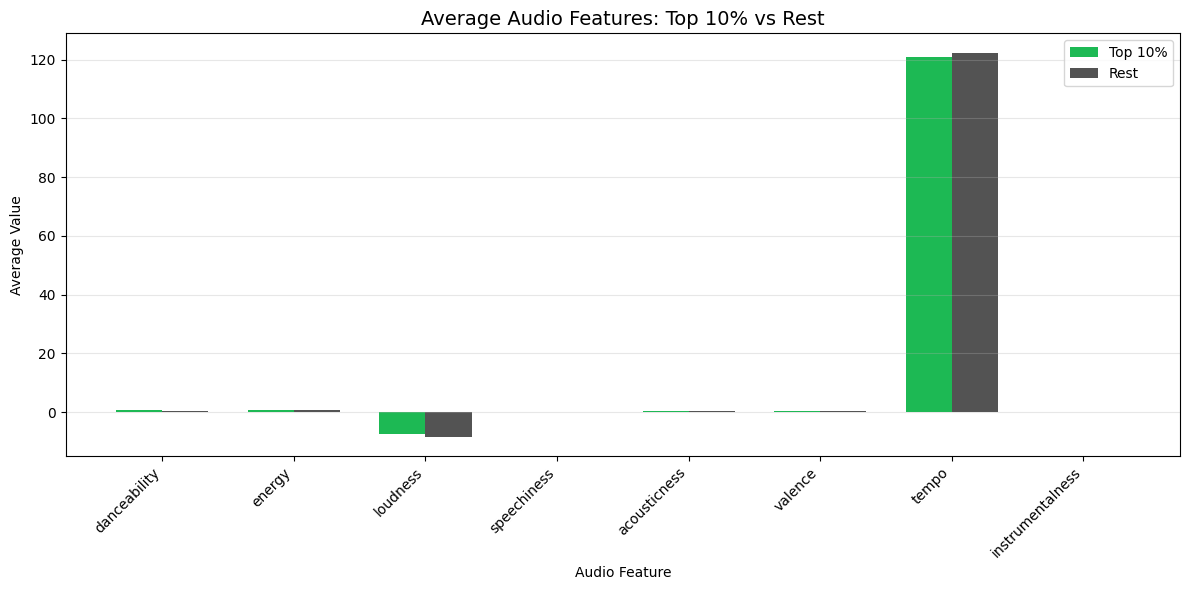

Figure saved!


In [7]:
# Bar chart — average audio features comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(features))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['top_10_percent'], 
               width, label='Top 10%', color='#1DB954')
bars2 = ax.bar(x + width/2, comparison['rest'], 
               width, label='Rest', color='#535353')

ax.set_title('Average Audio Features: Top 10% vs Rest', fontsize=14)
ax.set_xlabel('Audio Feature')
ax.set_ylabel('Average Value')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig("../figures/top10_vs_rest_features.png", dpi=300)
plt.show()
print("Figure saved!")

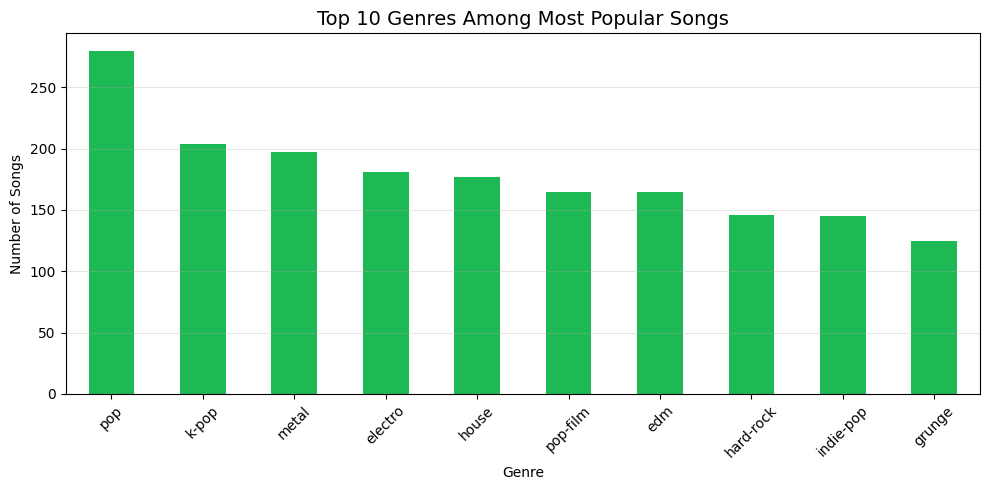

Figure saved!


In [8]:
# Bar chart — top genres in top 10%
fig, ax = plt.subplots(figsize=(10, 5))

top_genres.plot(kind='bar', ax=ax, color='#1DB954')

ax.set_title('Top 10 Genres Among Most Popular Songs', fontsize=14)
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Songs')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig("../figures/top10_genres.png", dpi=300)
plt.show()
print("Figure saved!")

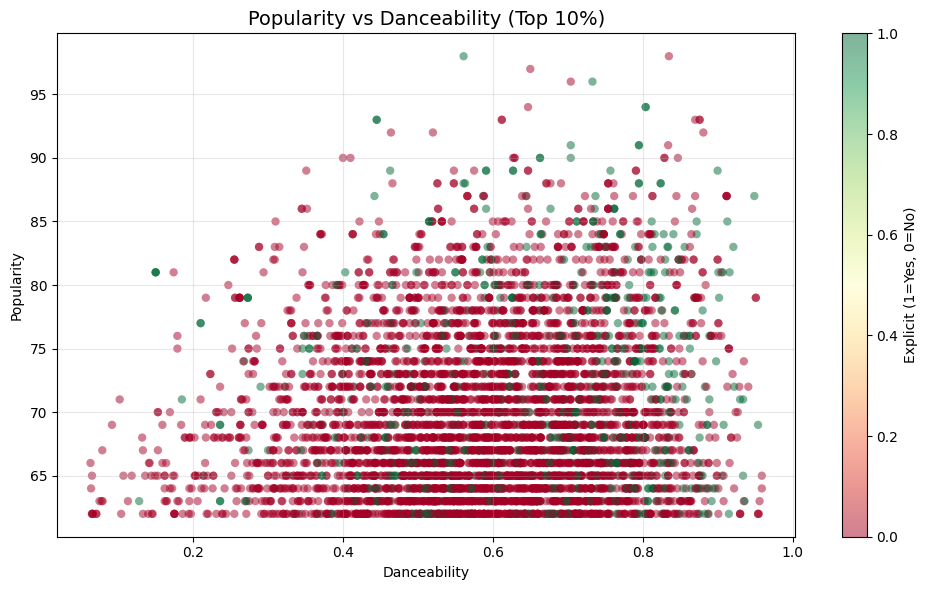

Figure saved!


In [9]:
# Scatter plot — popularity vs danceability colored by explicit
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    top10['danceability'],
    top10['popularity'],
    c=top10['explicit'],
    cmap='RdYlGn',
    alpha=0.5,
    edgecolors='none'
)

ax.set_title('Popularity vs Danceability (Top 10%)', fontsize=14)
ax.set_xlabel('Danceability')
ax.set_ylabel('Popularity')
plt.colorbar(scatter, label='Explicit (1=Yes, 0=No)')
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("../figures/top10_popularity_danceability.png", dpi=300)
plt.show()
print("Figure saved!")

## Key Findings — What Do Top 10% Most Popular Spotify Songs Have in Common?

### Audio Features
- Top 10% songs have **higher danceability** than the rest
- Top 10% songs tend to be **less instrumental** — more vocal/lyric driven
- Top 10% songs are slightly **louder** on average
- **Valence (happiness)** is slightly higher in popular songs

### Explicit Content
- **13.4%** of top 10% songs are explicit
- vs **7.8%** in the rest of songs
- Explicit songs are **almost twice as likely** to appear in the top 10%
- This suggests explicit content does correlate with higher popularity

### Genres
- The most popular genres are **pop, k-pop, and metal**
- Pop dominates with 280 songs, followed by k-pop (204) and metal (197)
- EDM, house, and electro also appear strongly — energy-driven genres perform well
- Indie-pop and grunge also make the top 10 — diverse taste in popular music

### Tempo
- Most popular songs fall in the **medium tempo** range (90-130 BPM)
- **54%** of top 10% songs are medium tempo
- Only **13%** are slow tempo — slow songs rarely hit the top

### Conclusion
The "formula" for a popular Spotify song appears to be:
- ✅ High danceability
- ✅ Moderate to high energy
- ✅ Low instrumentalness — vocal/lyric driven songs do better
- ✅ Medium tempo (90-130 BPM)
- ✅ Belongs to **pop, k-pop, metal, or EDM** genres
- ✅ Slightly more likely to be explicit

## Question 2 — Do Happy Songs Get More Popular or Do People Prefer Sad Songs?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../data/processed/spotify_cleaned.csv")
print("Loaded successfully!")
print(df.shape)

Loaded successfully!
(49999, 23)


In [2]:
# Define happy, neutral and sad songs based on valence
def mood_category(valence):
    if valence >= 0.7:
        return 'Happy'
    elif valence <= 0.3:
        return 'Sad'
    else:
        return 'Neutral'

df['mood'] = df['valence'].apply(mood_category)

print("Mood distribution:")
print(df['mood'].value_counts())

Mood distribution:
mood
Neutral    23521
Sad        14903
Happy      11575
Name: count, dtype: int64


In [3]:
# Average popularity by mood
mood_popularity = df.groupby('mood')['popularity'].agg(['mean', 'count', 'std'])
print("Average popularity by mood:")
print(mood_popularity.round(3))

Average popularity by mood:
           mean  count     std
mood                          
Happy    30.928  11575  22.207
Neutral  34.208  23521  22.871
Sad      33.567  14903  21.253


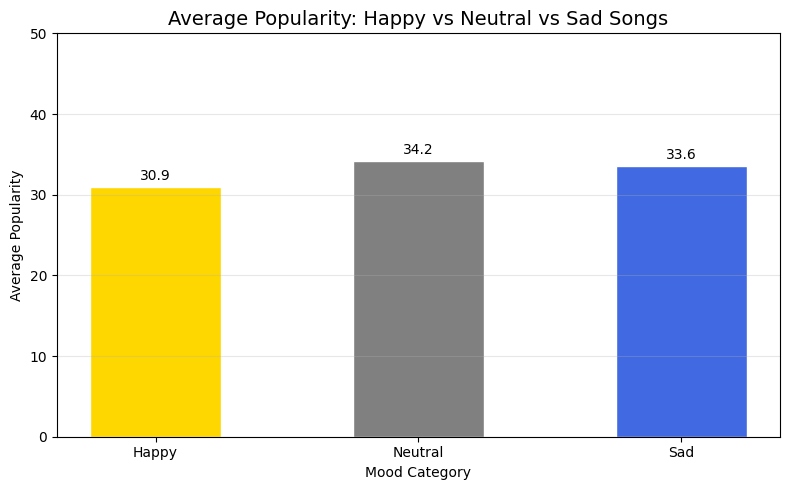

Figure saved!


In [4]:
# Bar plot — popularity by mood
fig, ax = plt.subplots(figsize=(8, 5))

colors = {'Happy': '#FFD700', 'Neutral': '#808080', 'Sad': '#4169E1'}
moods = mood_popularity.index.tolist()
values = mood_popularity['mean'].values

bars = ax.bar(moods,
              values,
              color=[colors[m] for m in moods],
              edgecolor='white',
              width=0.5)

ax.set_title('Average Popularity: Happy vs Neutral vs Sad Songs', fontsize=14)
ax.set_xlabel('Mood Category')
ax.set_ylabel('Average Popularity')
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 50)

fig.tight_layout()
fig.savefig("../figures/popularity_by_mood.png", dpi=300)
plt.show()
print("Figure saved!")

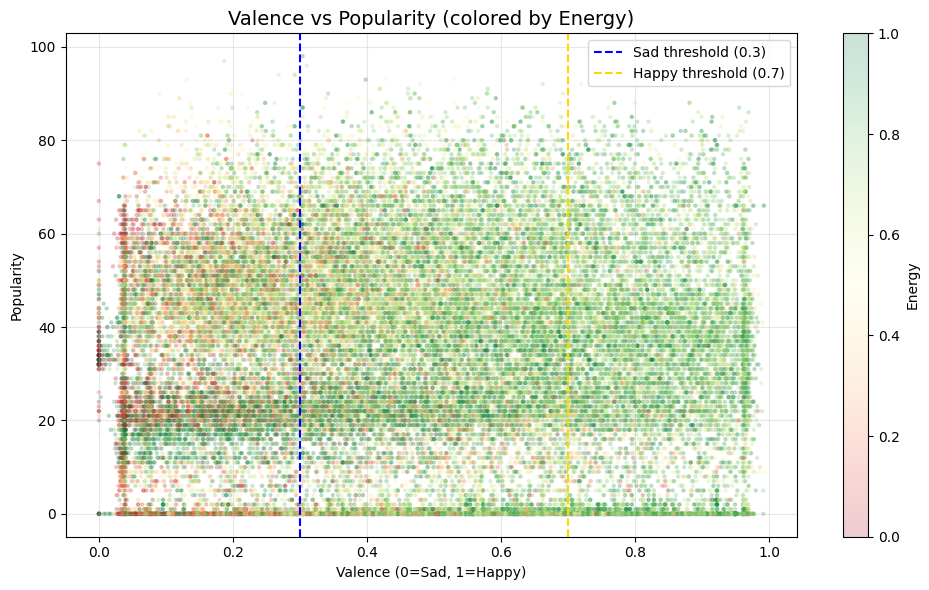

Figure saved!


In [5]:
# Scatter plot — valence vs popularity
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df['valence'],
    df['popularity'],
    c=df['energy'],
    cmap='RdYlGn',
    alpha=0.2,
    s=5
)

plt.colorbar(scatter, label='Energy')
ax.set_title('Valence vs Popularity (colored by Energy)', fontsize=14)
ax.set_xlabel('Valence (0=Sad, 1=Happy)')
ax.set_ylabel('Popularity')
ax.axvline(0.3, color='blue', linestyle='--', 
           linewidth=1.5, label='Sad threshold (0.3)')
ax.axvline(0.7, color='gold', linestyle='--', 
           linewidth=1.5, label='Happy threshold (0.7)')
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("../figures/valence_vs_popularity.png", dpi=300)
plt.show()
print("Figure saved!")

In [6]:
# Which genres are the happiest vs saddest?
genre_valence = df.groupby('track_genre')['valence'].mean().sort_values(ascending=False)

print("Top 5 happiest genres:")
print(genre_valence.head(5).round(3))
print()
print("Top 5 saddest genres:")
print(genre_valence.tail(5).round(3))

Top 5 happiest genres:
track_genre
salsa         0.810
forro         0.765
rockabilly    0.717
afrobeat      0.707
children      0.693
Name: valence, dtype: float64

Top 5 saddest genres:
track_genre
black-metal    0.196
new-age        0.179
ambient        0.169
iranian        0.159
sleep          0.057
Name: valence, dtype: float64


In [7]:
# Are sad songs more popular in specific genres?
mood_genre = df.groupby(['track_genre', 'mood'])['popularity'].mean().unstack(fill_value=0)
print("Popularity by mood per genre (first 10 genres):")
print(mood_genre.head(10).round(2))

Popularity by mood per genre (first 10 genres):
mood         Happy  Neutral    Sad
track_genre                       
acoustic     38.41    43.05  44.29
afrobeat     23.22    26.04  25.67
alt-rock     28.02    32.07  33.72
alternative  14.32    26.20  30.32
ambient      39.40    42.64  44.89
anime        48.74    49.59  47.16
black-metal  23.00    22.37  22.97
bluegrass    24.32    26.54  26.75
blues        25.06    35.31  33.72
brazil       43.70    45.54  46.37


In [8]:
# Correlation between valence and popularity
corr = df['valence'].corr(df['popularity'])
print(f"Correlation between valence and popularity: {corr:.4f}")
print()
if corr < 0:
    print("Negative correlation — sadder songs tend to be slightly more popular!")
else:
    print("Positive correlation — happier songs tend to be slightly more popular!")

Correlation between valence and popularity: -0.0385

Negative correlation — sadder songs tend to be slightly more popular!


## Key Findings — Question 2: Do Happy Songs Get More Popular or Do People Prefer Sad Songs?

### Mood Distribution
- Happy songs (valence >= 0.7): **11,575 songs (23%)**
- Neutral songs (0.3 < valence < 0.7): **23,521 songs (47%)**
- Sad songs (valence <= 0.3): **14,903 songs (30%)**

### Popularity by Mood
- Happy songs average popularity: **30.93**
- Neutral songs average popularity: **34.21**
- Sad songs average popularity: **33.57**
- Neutral songs are the most popular — extremes (very happy or very sad) perform worse

### Correlation
- Valence vs popularity correlation: **-0.0385**
- Negative correlation — sadder songs tend to be slightly more popular
- However the correlation is very weak — mood alone does not predict popularity

### Happiest vs Saddest Genres
- Happiest genres: **salsa (0.810), forro (0.765), rockabilly (0.717)**
- Saddest genres: **sleep (0.057), iranian (0.159), ambient (0.169)**

### Genre Mood Insight
- In most genres sad songs outperform happy songs
- Example: alternative sad songs score **30.32** vs happy **14.32**
- Acoustic sad songs score **44.29** vs happy **38.41**
- Anime is the exception — happy anime songs score **48.74** vs sad **47.16**

### Conclusion
Contrary to what many might expect, **people slightly prefer
neutral to sad songs over happy songs on Spotify**. The most
popular songs sit in the middle valence range (0.3-0.7) rather
than being overtly happy. The correlation of -0.0385 confirms
that happier songs are very slightly less popular on average.
This could suggest that listeners connect more emotionally with
melancholic or bittersweet music, or that genres dominating
the charts (pop, k-pop, metal) tend to have lower valence scores.
The takeaway: **don't make your song too happy if you want streams!**

## Question 4 — Do Shorter Songs Get More Popular Than Longer Ones on Spotify?

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../data/processed/spotify_cleaned.csv")
print("Loaded successfully!")
print(df.shape)

Loaded successfully!
(49999, 23)


In [12]:
# Check duration stats first
print("Duration in seconds — stats:")
print(f"Mean:   {df['duration_sec'].mean():.1f} sec")
print(f"Median: {df['duration_sec'].median():.1f} sec")
print(f"Min:    {df['duration_sec'].min():.1f} sec")
print(f"Max:    {df['duration_sec'].max():.1f} sec")

Duration in seconds — stats:
Mean:   228.2 sec
Median: 212.8 sec
Min:    8.6 sec
Max:    5237.3 sec


In [13]:
# Remove extreme outliers — songs over 10 minutes
df_clean = df[df['duration_sec'] <= 600].copy()
print(f"Songs removed as outliers: {len(df) - len(df_clean)}")
print(f"Remaining songs: {len(df_clean)}")

Songs removed as outliers: 271
Remaining songs: 49728


In [14]:
# Categorize songs by length
def length_category(sec):
    if sec < 150:
        return 'Short (< 2.5 min)'
    elif sec < 240:
        return 'Medium (2.5-4 min)'
    elif sec < 360:
        return 'Long (4-6 min)'
    else:
        return 'Very Long (> 6 min)'

df_clean['length_category'] = df_clean['duration_sec'].apply(length_category)

print("Song length distribution:")
print(df_clean['length_category'].value_counts())

Song length distribution:
length_category
Medium (2.5-4 min)     25992
Long (4-6 min)         13848
Short (< 2.5 min)       6705
Very Long (> 6 min)     3183
Name: count, dtype: int64


In [15]:
# Average popularity by length category
length_popularity = df_clean.groupby('length_category')['popularity'].agg(['mean', 'count', 'std'])

# Sort by duration order
order = ['Short (< 2.5 min)', 'Medium (2.5-4 min)', 
         'Long (4-6 min)', 'Very Long (> 6 min)']
length_popularity = length_popularity.reindex(order)

print("Average popularity by song length:")
print(length_popularity.round(3))

Average popularity by song length:
                       mean  count     std
length_category                           
Short (< 2.5 min)    30.531   6705  21.127
Medium (2.5-4 min)   33.922  25992  23.411
Long (4-6 min)       34.386  13848  21.060
Very Long (> 6 min)  29.419   3183  19.537


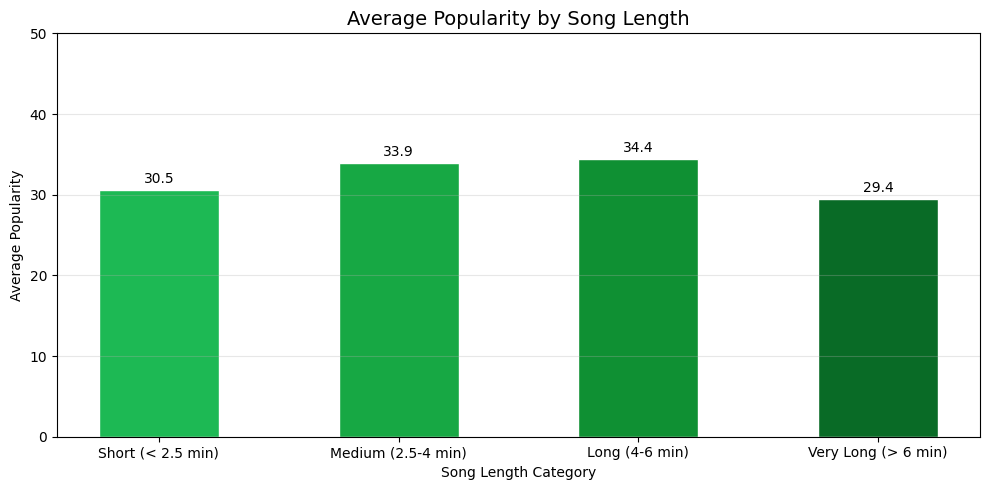

Figure saved!


In [16]:
# Bar plot — popularity by song length
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#1DB954', '#17A844', '#0F9033', '#096B26']
bars = ax.bar(order,
              length_popularity['mean'].values,
              color=colors,
              edgecolor='white',
              width=0.5)

ax.set_title('Average Popularity by Song Length', fontsize=14)
ax.set_xlabel('Song Length Category')
ax.set_ylabel('Average Popularity')
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 50)

fig.tight_layout()
fig.savefig("../figures/popularity_by_length.png", dpi=300)
plt.show()
print("Figure saved!")

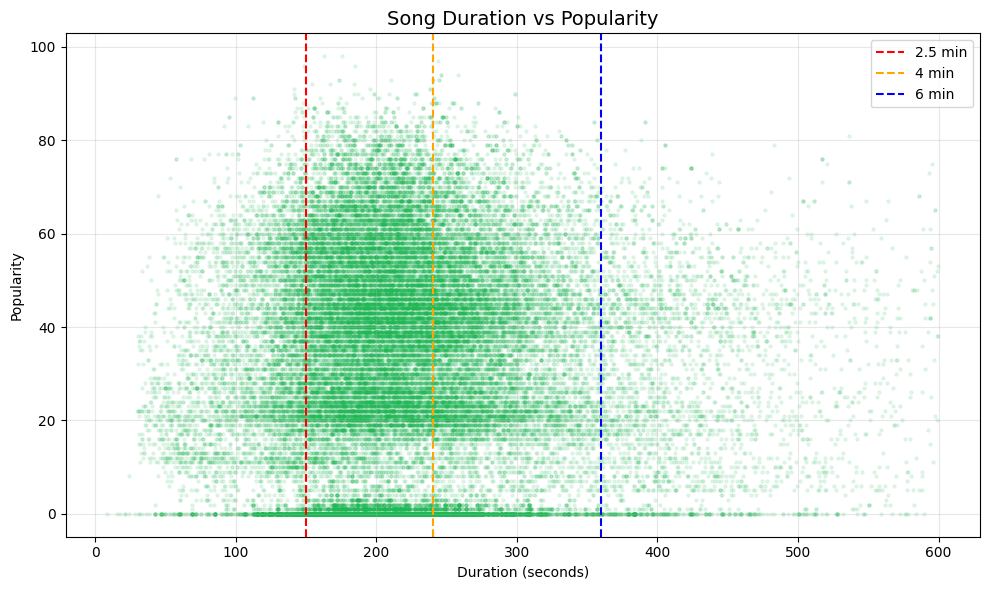

Figure saved!


In [17]:
# Scatter plot — duration vs popularity
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df_clean['duration_sec'],
    df_clean['popularity'],
    alpha=0.1,
    s=5,
    color='#1DB954'
)

ax.set_title('Song Duration vs Popularity', fontsize=14)
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Popularity')
ax.axvline(150, color='red', linestyle='--', 
           linewidth=1.5, label='2.5 min')
ax.axvline(240, color='orange', linestyle='--', 
           linewidth=1.5, label='4 min')
ax.axvline(360, color='blue', linestyle='--', 
           linewidth=1.5, label='6 min')
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("../figures/duration_vs_popularity.png", dpi=300)
plt.show()
print("Figure saved!")

In [18]:
# Correlation between duration and popularity
corr = df_clean['duration_sec'].corr(df_clean['popularity'])
print(f"Correlation between duration and popularity: {corr:.4f}")
print()
if corr < 0:
    print("Negative correlation — shorter songs tend to be more popular!")
else:
    print("Positive correlation — longer songs tend to be more popular!")

Correlation between duration and popularity: 0.0114

Positive correlation — longer songs tend to be more popular!


In [19]:
# Which genres have the shortest vs longest songs on average?
genre_duration = df_clean.groupby('track_genre')['duration_sec'].mean().sort_values()

print("Top 5 shortest song genres:")
print(genre_duration.head(5).round(1))
print()
print("Top 5 longest song genres:")
print(genre_duration.tail(5).round(1))

Top 5 shortest song genres:
track_genre
grindcore    127.3
children     138.6
study        141.4
sad          153.2
disney       154.0
Name: duration_sec, dtype: float64

Top 5 longest song genres:
track_genre
gospel            306.4
techno            308.4
chicago-house     348.8
detroit-techno    349.3
minimal-techno    360.7
Name: duration_sec, dtype: float64


## Key Findings — Question 4: Do Shorter Songs Get More Popular?

### Song Length Distribution
- Short (< 2.5 min): **6,705 songs (13.5%)**
- Medium (2.5-4 min): **25,992 songs (52.3%)** — majority of songs
- Long (4-6 min): **13,848 songs (27.8%)**
- Very Long (> 6 min): **3,183 songs (6.4%)**
- Removed **271 outliers** over 10 minutes before analysis

### Popularity by Length
- Short songs average popularity: **30.53**
- Medium songs average popularity: **33.92**
- Long songs average popularity: **34.39** ← highest!
- Very long songs average popularity: **29.42** ← lowest!
- The sweet spot is **4-6 minutes** — not too short, not too long

### Correlation
- Duration vs popularity correlation: **+0.0114**
- Very weak positive correlation — slightly longer songs
  perform marginally better
- However the effect is tiny — length alone does not
  predict popularity

### Genre Insights
- Shortest song genres: **grindcore (127s), children (139s),
  study (141s)**
- Longest song genres: **minimal-techno (361s),
  detroit-techno (349s), chicago-house (349s)**
- Electronic/techno genres tend to have the longest songs
- Children and study music tend to be the shortest

### Conclusion
Contrary to the popular belief that shorter songs perform
better in the streaming era, the data shows that **medium
to long songs (2.5-6 minutes) actually score higher in
popularity** than very short or very long ones. The sweet
spot appears to be **4-6 minutes** with an average
popularity of 34.39. Very short songs (under 2.5 min) and
very long songs (over 6 min) both underperform. The
correlation of +0.0114 is extremely weak however, suggesting
that **song length has almost no real impact on popularity**
— other factors matter much more.